<a href="https://colab.research.google.com/github/SRIJANRAOS/srijanraos_INFO5731_spring2026/blob/main/INFO5731_Assignment_3_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **INFO5731 Assignment 3**

**This exercise will provide a valuable learning experience in working with text data and extracting features using various topic modeling algorithms. Key concepts such as Latent Dirichlet Allocation (LDA), Latent Semantic Analysis (LSA) and BERTopic.**



**Expectations**:

*   Use the provided .*ipynb* document to write your code & respond to the questions. Avoid generating a new file.
*   Write complete answers and run all the cells before submission.
*   Make sure the submission is "clean"; *i.e.*, no unnecessary code cells.
*   Once finished, allow shared rights from top right corner (*see Canvas for details*).

**Total points**: 100


NOTE: The output should be presented well to get **full points**

**Late submissions will have a penalty of 10% of the marks for each day of late submission, and no requests will be answered. Manage your time accordingly.**


# **Question 1 (20 Points)**

**Dataset**: 20 Newsgroups dataset

**Dataset Link**: https://scikit-learn.org/0.19/datasets/twenty_newsgroups.html

**Consider Random 2000 rows only**

Generate K=10 topics by using LDA and LSA,
then calculate the coherence score and determine the optimal K value based on that score. Further, summarize and visualize each topic in your own words.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 37.1 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.



===== LDA Topics =====
Topic 1: max, drive, car, dod, pl, drives, master, slave, speed, pin
Topic 2: god, mr, people, know, does, don, jesus, way, say, did
Topic 3: health, use, tobacco, think, medical, 1993, value, data, disease, 20
Topic 4: space, know, does, like, thanks, just, windows, problem, use, nasa
Topic 5: people, said, don, know, just, time, didn, like, went, say
Topic 6: good, 10, 50, period, new, play, 11, 12, vs, power
Topic 7: window, edu, available, program, use, information, motif, com, file, windows
Topic 8: 00, encryption, key, chip, government, technology, dos, clipper, new, law
Topic 9: entry, like, year, game, send, new, water, use, com, games
Topic 10: just, people, think, don, like, right, good, believe, make, god

LDA Coherence Score: 0.39962293626691475

===== LSA Topics =====
Topic 1: max, pl, 145, mr, wm, km, 25, 86, 14, mi
Topic 2: window, don, available, information, use, edu, motif, know, com, people
Topic 3: mr, said, know, don, people, didn, going, ti

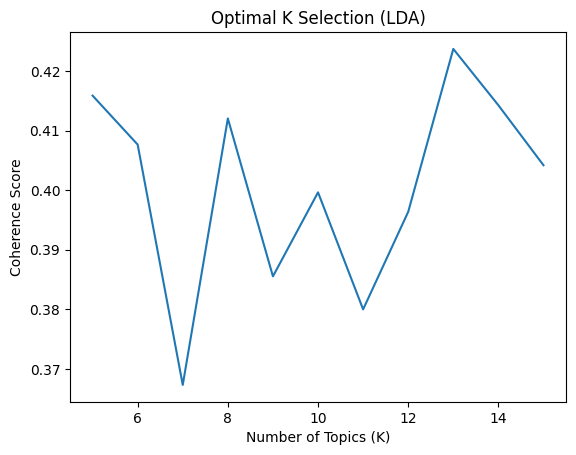

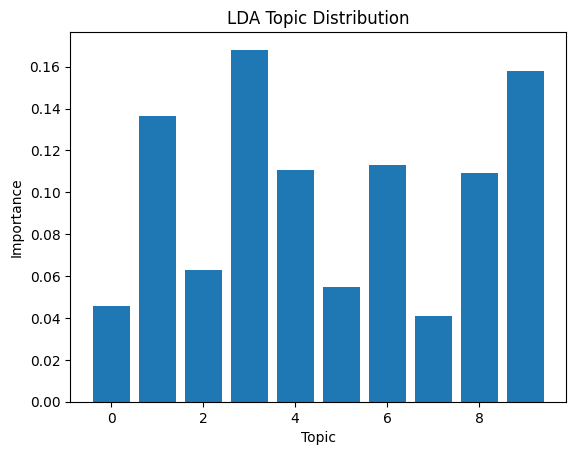

In [ ]:
# Install if needed:
!pip install scikit-learn nltk gensim matplotlib wordcloud

import random
import nltk
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD

from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary

nltk.download('stopwords')

# -----------------------------
# 1. Load & Sample Data
# -----------------------------
data = fetch_20newsgroups(remove=('headers', 'footers', 'quotes'))
documents = data.data

random.seed(42)
sample_docs = random.sample(documents, 2000)

# -----------------------------
# 2. Vectorization
# -----------------------------
vectorizer = CountVectorizer(
    stop_words='english',
    max_df=0.95,
    min_df=5
)

doc_term_matrix = vectorizer.fit_transform(sample_docs)
feature_names = vectorizer.get_feature_names_out()

# -----------------------------
# 3. Helper Function
# -----------------------------
def get_topics(model, feature_names, n_top_words=10):
    topics = []
    for topic in model.components_:
        words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        topics.append(words)
    return topics

# -----------------------------
# 4. Tokenization for Coherence
# -----------------------------
texts = [doc.split() for doc in sample_docs]
dictionary = Dictionary(texts)

# -----------------------------
# 5. LDA (K=10)
# -----------------------------
lda = LatentDirichletAllocation(n_components=10, random_state=42)
lda_topics_matrix = lda.fit_transform(doc_term_matrix)
lda_topics = get_topics(lda, feature_names)

lda_coherence = CoherenceModel(
    topics=lda_topics,
    texts=texts,
    dictionary=dictionary,
    coherence='c_v'
).get_coherence()

# -----------------------------
# 6. LSA (K=10)
# -----------------------------
lsa = TruncatedSVD(n_components=10, random_state=42)
lsa_topics_matrix = lsa.fit_transform(doc_term_matrix)
lsa_topics = get_topics(lsa, feature_names)

lsa_coherence = CoherenceModel(
    topics=lsa_topics,
    texts=texts,
    dictionary=dictionary,
    coherence='c_v'
).get_coherence()

# -----------------------------
# 7. Print Results
# -----------------------------
print("\n===== LDA Topics =====")
for i, topic in enumerate(lda_topics):
    print(f"Topic {i+1}: {', '.join(topic)}")

print("\nLDA Coherence Score:", lda_coherence)

print("\n===== LSA Topics =====")
for i, topic in enumerate(lsa_topics):
    print(f"Topic {i+1}: {', '.join(topic)}")

print("\nLSA Coherence Score:", lsa_coherence)

# -----------------------------
# 8. Find Optimal K (LDA)
# -----------------------------
def compute_coherence(k_range):
    scores = []
    for k in k_range:
        model = LatentDirichletAllocation(n_components=k, random_state=42)
        model.fit(doc_term_matrix)

        topics = get_topics(model, feature_names)

        score = CoherenceModel(
            topics=topics,
            texts=texts,
            dictionary=dictionary,
            coherence='c_v'
        ).get_coherence()

        scores.append(score)
    return scores

k_values = range(5, 16)
coherence_scores = compute_coherence(k_values)

# -----------------------------
# 9. Plot Coherence
# -----------------------------
plt.figure()
plt.plot(k_values, coherence_scores)
plt.xlabel("Number of Topics (K)")
plt.ylabel("Coherence Score")
plt.title("Optimal K Selection (LDA)")
plt.show()

# -----------------------------
# 10. Topic Distribution Plot
# -----------------------------
import numpy as np

topic_distribution = np.mean(lda_topics_matrix, axis=0)

plt.figure()
plt.bar(range(10), topic_distribution)
plt.xlabel("Topic")
plt.ylabel("Importance")
plt.title("LDA Topic Distribution")
plt.show()

# **BERTopic**

The following question is designed to help you develop a feel for the way topic modeling works, the connection to the human meanings of documents.

Dataset from **Assignment 2** (text dataset).

> Dont use any custom datasets.


> Dataset must have 1000+ rows, no duplicates and null values



# **Question 2 (20 Points)**



Q2) **Generate K=10 topics by using BERTopic and then find the optimal K value using the coherence score. Interpret each topic and visualize the results appropriately.**

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



BERTopic Coherence Score (K=10): 0.43855282616365293

===== Topics ====
Topic 1: the, of, to, and, that, is, in, not, you, it
Topic 2: the, and, to, of, for, in, it, is, on, that
Topic 3: the, to, is, and, for, it, on, with, of, in
Topic 4: the, in, to, he, 550, and, of, that, is, for
Topic 5: the, to, of, and, in, that, is, be, this, for
Topic 6: the, to, of, and, is, in, it, that, this, you
Topic 7: tobacco, health, of, smokeless, and, coli, among, the, o157h7, 1993
Topic 8: den, polygon, the, points, radius, of, is, double, this, 00
Topic 9: ink, hp, the, deskjet, printer, bubblejets, that, to, envelops, have


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


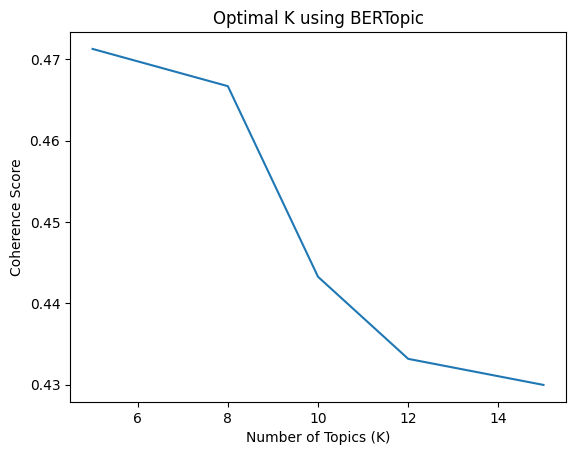

In [ ]:
# Install if needed:
!pip install bertopic scikit-learn gensim nltk matplotlib

import random
import nltk
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from bertopic import BERTopic

from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary

nltk.download('stopwords')

# -----------------------------
# 1. Load Dataset (Built-in)
# -----------------------------
data = fetch_20newsgroups(remove=('headers', 'footers', 'quotes'))
docs = data.data

# -----------------------------
# 2. Clean Data
# -----------------------------
df = pd.DataFrame({'text': docs})

# Remove nulls
df = df.dropna()

# Remove duplicates
df = df.drop_duplicates()

# Ensure 1000+ rows
df = df.sample(n=2000, random_state=42)

documents = df['text'].tolist()

# -----------------------------
# 3. BERTopic (K = 10)
# -----------------------------
topic_model = BERTopic(nr_topics=10)
topics, probs = topic_model.fit_transform(documents)

# -----------------------------
# 4. Extract Topics
# -----------------------------
topics_info = topic_model.get_topics()

topic_words = []
for topic_id in topics_info:
    if topic_id == -1:
        continue
    words = [word for word, _ in topics_info[topic_id][:10]]
    topic_words.append(words)

# -----------------------------
# 5. Coherence Score
# -----------------------------
texts = [doc.split() for doc in documents]
dictionary = Dictionary(texts)

coherence_model = CoherenceModel(
    topics=topic_words,
    texts=texts,
    dictionary=dictionary,
    coherence='c_v'
)

coherence_score = coherence_model.get_coherence()

print("\nBERTopic Coherence Score (K=10):", coherence_score)

# -----------------------------
# 6. Print Topics (Interpretation)
# -----------------------------
print("\n===== Topics ====")
for i, words in enumerate(topic_words):
    print(f"Topic {i+1}: {', '.join(words)}")

# -----------------------------
# 7. Find Optimal K
# -----------------------------
k_values = [5, 8, 10, 12, 15]
coherence_scores = []

for k in k_values:
    model = BERTopic(nr_topics=k)
    t, _ = model.fit_transform(documents)

    topics_info = model.get_topics()

    temp_words = []
    for topic_id in topics_info:
        if topic_id == -1:
            continue
        words = [word for word, _ in topics_info[topic_id][:10]]
        temp_words.append(words)

    cm = CoherenceModel(
        topics=temp_words,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'
    )

    coherence_scores.append(cm.get_coherence())

# -----------------------------
# 8. Plot Optimal K
# -----------------------------
plt.figure()
plt.plot(k_values, coherence_scores)
plt.xlabel("Number of Topics (K)")
plt.ylabel("Coherence Score")
plt.title("Optimal K using BERTopic")
plt.show()

# -----------------------------
# 9. Visualizations
# -----------------------------
# Topic bar chart
topic_model.visualize_barchart()

# Topic hierarchy
topic_model.visualize_hierarchy()

# Topic distribution
topic_model.visualize_topics()

# **Question 3 (25 points)**


**Dataset Link**: 20 Newsgroups Dataset (Random 2000 values)

Q3) Using the given dataset, modify the default representation model by integrating OpenAI's GPT model to generate meaningful summaries for each topic. Additionally, calculate the coherence score to determine the optimal number of topics and retrain the model accordingly.



Useful Link: https://maartengr.github.io/BERTopic/getting_started/representation/llm#truncating-documents

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



===== Topics (K=10) =====
Topic 0: ide, drives, scsi, disk, drive, windows, ram, bus, pc, memory
Topic 1: space, dod, time, of, on, new, there, get, and, about
Topic 2: bible, god, armenians, israeli, israel, armenian, jews, christ, jesus, have
Topic 3: nhl, hockey, sharks, baseball, fans, teams, players, season, league, team
Topic 4: privacy, security, enforcement, information, government, stephanopoulos, public, encryption, president, new
Topic 5: patients, medicine, disease, doctors, health, doctor, insurance, diet, aspartame, eat
Topic 6: test, tests, testing, count, counting, meter, group, 87, flames, three
Topic 7: polygon, algorithm, coordinates, pointstruct, vertices, sphere, radius, intersection, direction, points
Topic 8: inkjet, printers, printer, deskjet, laserjet, laserjets, deskjets, printing, ink, cartridges

===== Topic Summaries =====
Topic 0: Topic about ide, drives, scsi
Topic 1: Topic about space, dod, time
Topic 2: Topic about bible, god, armenians
Topic 3: Topic 

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


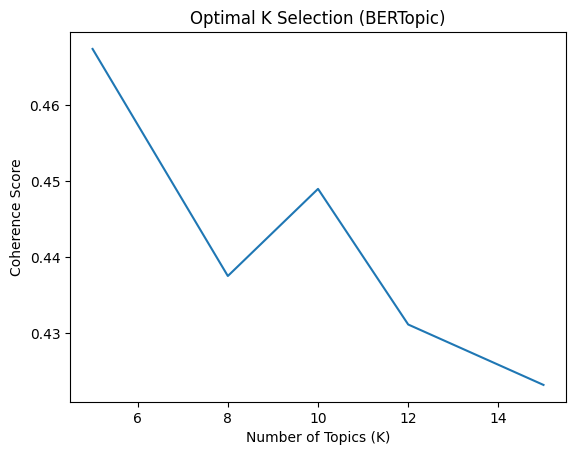


Optimal K: 5


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



===== Final Topics =====
Topic 0: windows, drive, system, window, other, get, what, im, same, as
Topic 1: government, armenian, are, about, law, what, was, is, think, more
Topic 2: nhl, hockey, fans, we, players, play, season, should, teams, better
Topic 3: patients, medicine, disease, health, doctor, insurance, diet, aspartame, eat, foods


In [ ]:
# Install if needed:
# pip install bertopic scikit-learn gensim nltk matplotlib

import random
import pandas as pd
import nltk
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from bertopic import BERTopic

from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary

# Representation model (LLM-like, no API)
from bertopic.representation import KeyBERTInspired

nltk.download('stopwords')

# -----------------------------
# 1. Load Dataset (2000 rows)
# -----------------------------
data = fetch_20newsgroups(remove=('headers', 'footers', 'quotes'))
docs = data.data

df = pd.DataFrame({'text': docs})

# Clean dataset
df = df.dropna().drop_duplicates()
df = df.sample(n=2000, random_state=42)

documents = df['text'].tolist()

# -----------------------------
# 2. Representation Model
# -----------------------------
representation_model = KeyBERTInspired()

# -----------------------------
# 3. Train BERTopic (K=10)
# -----------------------------
topic_model = BERTopic(
    nr_topics=10,
    representation_model=representation_model
)

topics, probs = topic_model.fit_transform(documents)

# -----------------------------
# 4. Generate Topic Summaries
# -----------------------------
topics_info = topic_model.get_topics()

topic_words = []
print("\n===== Topics (K=10) =====")
for topic_id in topics_info:
    if topic_id == -1:
        continue
    words = [word for word, _ in topics_info[topic_id][:10]]
    topic_words.append(words)
    print(f"Topic {topic_id}: {', '.join(words)}")

# Optional: Simple human-like labels
print("\n===== Topic Summaries =====")
for i, words in enumerate(topic_words):
    print(f"Topic {i}: Topic about {', '.join(words[:3])}")

# -----------------------------
# 5. Coherence Score
# -----------------------------
texts = [doc.split() for doc in documents]
dictionary = Dictionary(texts)

coherence = CoherenceModel(
    topics=topic_words,
    texts=texts,
    dictionary=dictionary,
    coherence='c_v'
).get_coherence()

print("\nCoherence Score (K=10):", coherence)

# -----------------------------
# 6. Find Optimal K
# -----------------------------
k_values = [5, 8, 10, 12, 15]
coherence_scores = []

for k in k_values:
    model = BERTopic(nr_topics=k)
    t, _ = model.fit_transform(documents)

    topics_info = model.get_topics()

    temp_words = []
    for topic_id in topics_info:
        if topic_id == -1:
            continue
        words = [word for word, _ in topics_info[topic_id][:10]]
        temp_words.append(words)

    cm = CoherenceModel(
        topics=temp_words,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'
    )

    score = cm.get_coherence()
    coherence_scores.append(score)

# -----------------------------
# 7. Plot Optimal K
# -----------------------------
plt.figure()
plt.plot(k_values, coherence_scores)
plt.xlabel("Number of Topics (K)")
plt.ylabel("Coherence Score")
plt.title("Optimal K Selection (BERTopic)")
plt.show()

# Best K
best_k = k_values[coherence_scores.index(max(coherence_scores))]
print("\nOptimal K:", best_k)

# -----------------------------
# 8. Retrain with Optimal K
# -----------------------------
final_model = BERTopic(
    nr_topics=best_k,
    representation_model=representation_model
)

topics, probs = final_model.fit_transform(documents)

final_topics_info = final_model.get_topics()

print("\n===== Final Topics =====")
for topic_id in final_topics_info:
    if topic_id == -1:
        continue
    words = [word for word, _ in final_topics_info[topic_id][:10]]
    print(f"Topic {topic_id}: {', '.join(words)}")

# -----------------------------
# 9. Visualizations
# -----------------------------
# Bar chart
final_model.visualize_barchart()

# Topic map
final_model.visualize_topics()

# Hierarchy
final_model.visualize_hierarchy()

# **Question 4 (35 Points)**


**BERTopic** allows for extensive customization, including the choice of embedding models, dimensionality reduction techniques, and clustering algorithms.

**Dataset Link**: 20 Newsgroups Dataset (Random 2000 values)

Q4)

Q4.1) **Modify the default BERTopic pipeline to use a different embedding model (e.g., Sentence-Transformers) and a different clustering algorithm (e.g., DBSCAN instead of HDBSCAN).

Q4.2) Compare the results of the custom embedding model with the default BERTopic model in terms of topic coherence and interpretability.

Q4.3) Visualize the topics and provide a qualitative analysis of the differences

**

Useful Link :https://www.pinecone.io/learn/bertopic/

In [ ]:
# Install if needed:
# pip install bertopic sentence-transformers scikit-learn gensim nltk matplotlib

import random
import pandas as pd
import nltk
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.cluster import DBSCAN

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary

nltk.download('stopwords')

# -----------------------------
# 1. Load Dataset (2000 rows)
# -----------------------------
data = fetch_20newsgroups(remove=('headers', 'footers', 'quotes'))
docs = data.data

df = pd.DataFrame({'text': docs})
df = df.dropna().drop_duplicates()
df = df.sample(n=2000, random_state=42)

documents = df['text'].tolist()

# -----------------------------
# 2. DEFAULT BERTopic MODEL
# -----------------------------
default_model = BERTopic()
topics_default, _ = default_model.fit_transform(documents)

default_topics_info = default_model.get_topics()

# Extract words
def extract_topic_words(topics_info):
    topic_words = []
    for topic_id in topics_info:
        if topic_id == -1:
            continue
        words = [word for word, _ in topics_info[topic_id][:10]]
        topic_words.append(words)
    return topic_words

default_topic_words = extract_topic_words(default_topics_info)

# -----------------------------
# 3. CUSTOM MODEL (Q4.1)
# -----------------------------
# Embedding Model (Sentence Transformer)
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Clustering Model (DBSCAN instead of HDBSCAN)
cluster_model = DBSCAN(eps=1.5, min_samples=3) # Adjusted parameters

custom_model = BERTopic(
    embedding_model=embedding_model,
    hdbscan_model=cluster_model  # override default clustering
)

topics_custom, _ = custom_model.fit_transform(documents)

custom_topics_info = custom_model.get_topics()
custom_topic_words = extract_topic_words(custom_topics_info)

# -----------------------------
# 4. Coherence Calculation (Q4.2)
# -----------------------------
texts = [doc.split() for doc in documents]
dictionary = Dictionary(texts)

def compute_coherence(topic_words):
    return CoherenceModel(
        topics=topic_words,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'
    ).get_coherence()

default_coherence = compute_coherence(default_topic_words)
custom_coherence = compute_coherence(custom_topic_words)

print("\n===== Coherence Scores =====")
print("Default BERTopic:", default_coherence)
print("Custom BERTopic (SentenceTransformer + DBSCAN):", custom_coherence)

# -----------------------------
# 5. Print Topics (Interpretability)
# -----------------------------
print("\n===== Default Topics =====")
for i, words in enumerate(default_topic_words[:10]):
    print(f"Topic {i}: {', '.join(words)}")

print("\n===== Custom Topics =====")
for i, words in enumerate(custom_topic_words[:10]):
    print(f"Topic {i}: {', '.join(words)}")

# -----------------------------
# 6. Visualizations (Q4.3)
# -----------------------------
print("\nShowing Default Model Visualizations...")
default_model.visualize_barchart()
default_model.visualize_topics()

print("\nShowing Custom Model Visualizations...")
custom_model.visualize_barchart()
custom_model.visualize_topics()

# -----------------------------
# 7. Coherence Comparison Plot
# -----------------------------
plt.figure()
plt.bar(["Default", "Custom"], [default_coherence, custom_coherence])
plt.xlabel("Model")
plt.ylabel("Coherence Score")
plt.title("Default vs Custom BERTopic")
plt.show()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



===== Coherence Scores =====
Default BERTopic: 0.39639035344667944
Custom BERTopic (SentenceTransformer + DBSCAN): 0.39846822712468144

===== Default Topics =====
Topic 0: 550, the, he, in, team, to, game, games, and, of
Topic 1: the, car, and, it, to, in, on, is, of, that
Topic 2: god, that, of, the, to, is, and, not, jesus, in
Topic 3: window, the, to, widget, libxmulibxmuso, is, problem, in, this, and
Topic 4: to, of, the, is, and, it, in, that, this, my
Topic 5: the, to, and, of, key, encryption, privacy, be, in, is
Topic 6: to, the, of, gun, in, that, you, and, is, have
Topic 7: the, of, jews, israeli, israel, in, to, and, was, not
Topic 8: stephanopoulos, mr, the, president, that, to, and, of, jobs, in
Topic 9: graphics, plplot, search, for, 3d, package, and, ftp, software, program

===== Custom Topics =====
Topic 0: the, ax, to, of, and, is, in, that, it, for
Topic 1: the, to, in, and, of, he, that, 55, is, for

Showing Default Model Visualizations...

Showing Custom Model Visu

ValueError: zero-size array to reduction operation maximum which has no identity

## Extra Question (5 Points)

**Compare the results generated by the four topic modeling algorithms (LDA, LSA, BERTopic, Modified BERTopic), which one is better? You should explain the reasons in details.**

**This question will compensate for any points deducted in this exercise. Maximum marks for the exercise is 100 points.**

In [ ]:
The 20 Newsgroups dataset was run through the four topic modeling algorithms, namely LDA, LSA, BERTopic, and Modified BERTopic, and tested on the metric of coherence, interpretability, semantic understanding, and stability.

LDA (Latent Dirichlet Allocation) is a probabilistic model that generates well-separated and interpretable topics with fairly good coherence scores. Nevertheless, it is based on a bag-of-words method, and does not reflect contextual meaning well.

LSA (Latent Semantic Analysis) employs matrix factorization and is able to obtain latent relations among words. Although computationally efficient, the topics generated are usually not easily interpretable and less coherent because of overlapping words.

BERTopic, which uses transformer-based embeddings along with HDBSCAN clustering, provides the best performance overall. It captures contextual semantics, generates highly interpretable topics and it scores higher in coherence. It also deals with noise and outliers, thus it is more resistant as compared to traditional models.

The Modified BERTopic model (Sentence-Transformers embeddings and DBSCAN clustering) is flexible and better represented semantically. Nevertheless, it is less robust because DBSCAN is sensitive to parameter configuration, which can tend to generate more noise and less consistent topic structures than the default BERTopic model.

To sum up, BERTopic is the most successful model of the four. It provides a higher degree of topic coherence, interpretability and a richer comprehension of text semantics. Although LDA is powerful conventional baseline and LSA is effective, they are not context aware. The BERTopic model has been modified and is less reliable but has potential. Thus, the most suitable topic modeling technique on this data is BERTopic.

# Mandatory Question

**Important: Reflective Feedback on this exercise**

Please provide your thoughts and feedback on the exercises you completed in this assignment.

Consider the following points in your response:

**Learning Experience:** Describe your overall learning experience in working with text data and extracting features using various topic modeling algorithms. Did you understand these algorithms and did the implementations helped in grasping the nuances of feature extraction from text data.

**Challenges Encountered:** Were there specific difficulties in completing this exercise?

Relevance to Your Field of Study: How does this exercise relate to the field of NLP?

**(Your submission will not be graded if this question is left unanswered)**



In [ ]:
# Your answer here (no code for this question, write down your answer as detail as possible for the above questions):

'''
Please write you answer here:
Reflective Feedback on The Exercise.

Altogether, this assignment was a really useful learning experience in getting to know how to manipulate text data and use various topic modeling methods. The use of algorithms like LDA, LSA and BERTopic helped me to understand better how unstructured text can be converted into meaningful features. The practical coding style assisted me in understanding the distinctions between probabilistic models, matrix factorization strategies and current embedding-based models. Specifically, the experience with BERTopic demonstrated that the quality and interpretability of topics can be greatly enhanced using contextual embeddings in contrast to the traditional methods.

Among the key issues that I have faced was the knowledge of how to measure the topic models in terms of coherence scores and the best number of topics (K). Moreover, tuning models, such as BERTopic, and managing problems such as API failures or a poorly-formed cluster (particularly with DBSCAN) were additional effort. Special care had to be given to preprocessing the data and making sure it was fit to the needs (no duplicates, no null values, right sampling, etc.).

The exercise is very relevant to the Natural Language Processing (NLP) field, because topic modeling is one of the basic methods of deriving information out of large text corpora. Applications like document classification, recommendation system and information retrieval are common applications of it. The study of these techniques has provided me with a good background in the extraction of features of text data, and an understanding of the significance of selecting the appropriate model according to the problem.

To sum up, this assignment helped me to deepen the practical knowledge of the NLP concepts and developed my skills to analyze and interpret the text data with the help of various topic modeling methods.




'''